![Banner sesión 5](https://github.com/cvail-research/Hands-on-Computer-Vision/blob/main/sesiones/sesion5/banner_sesion_5.png?raw=true)

# <center> **04. Estimación pasiva de la profundidad** </center>

La estimación pasiva de la profundidad es el conjunto de técnicas y algoritmos para estimar la distancia observada de objetos para permitir una comprensión tridimensional (3D) del entorno circundante. Durante esta sesión vamos a aplicar los conceptos explicados, **para estimar la disparidad en imágenes estéreo prediseñadas mediante diversas técnicas de programación y así obtener los mapas de disparidad y profundidad.**

# **Contenido**

[**0. Introducción a la visión estéreo**](#tema1)

[**1. Caso 1: Imagenes Rectificadas**](#tema2)

&emsp;&emsp;[**1.1. Disparidad**](#tema3)

&emsp;&emsp;[**1.2. Profundidad**](#tema4)

&emsp;&emsp;[**1.3. PointCloud - 3D**](#tema5)

[**2. Caso 2: Imágenes No Rectificadas**](#tema6)

&emsp;&emsp;[**2.1 Calibración de camara**](#tema7)

&emsp;&emsp;[**2.2. Rectificación**](#tema8)

&emsp;&emsp;&emsp;&emsp;&emsp; [**2.2.1 Conceptos**](#tema9)

&emsp;&emsp;&emsp;&emsp;&emsp; [**2.2.2 KeyPoints**](#tema11)

&emsp;&emsp;&emsp;&emsp;&emsp;[**2.2.3 Matriz Fundamental**](#tema12)

&emsp;&emsp;&emsp;&emsp;&emsp;[**2.2.4 Lineas epipolares**](#tema13)

&emsp;&emsp;&emsp;&emsp;&emsp;[**2.2.5 Homografías**](#tema14)

&emsp;&emsp;[**2.3 Disparidad**](#tema15)

&emsp;&emsp;[**2.4 Profundidad**](#tema16)

&emsp;&emsp;[**2.5 PointCloud - 3D**](#tema17)

In [ ]:
#@title **Instalar Paquetes**
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("plotly") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "plotly"])


In [ ]:
#@title **Cargar librerias**
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import requests
from PIL import Image
from io import BytesIO
import plotly.graph_objects as go
from PIL import Image
import random
import ipywidgets as widgets
from IPython.display import display
import matplotlib.gridspec as gridspec
from pathlib import Path
from imageio.v3 import imread

In [ ]:
#@title Funciones Necesarias { display-mode: "form" }
from pathlib import Path


def resolver_ruta_sesion5(*partes):
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        for raiz in (base, base / "sesiones" / "sesion5"):
            ruta = raiz.joinpath(*partes)
            if ruta.exists():
                return ruta
    return Path(*partes)


def descargar_imagenes(carpeta, color=None):
    base_url = "https://raw.githubusercontent.com/jjardila1220/Hands-on-Computer-Vision/main/sesiones/sesion5/Datasets/ALL-2views/{}/{}"

    im0, im1 = None, None
    size = (384, 288)  # Tamaño deseado: (ancho, alto)

    for img in ['view1.png', 'view5.png']:
        ruta_local = resolver_ruta_sesion5("Datasets", "ALL-2views", carpeta, img)
        if ruta_local.exists():
            image = Image.open(ruta_local)
        else:
            url = base_url.format(carpeta, img)
            response = requests.get(url)
            if response.status_code == 200:
                image = Image.open(BytesIO(response.content))
            else:
                raise FileNotFoundError(f"No se encontró {ruta_local} ni se pudo descargar {url}")
        image = image.resize(size, Image.LANCZOS)
        if img == 'view1.png':
            im0 = image
        else:
            im1 = image

    if color == "Color":
      imgL_np = np.array(im0)
      imgR_np = np.array(im1)
    else:
      imgL_np = np.array(im0.convert('L'))
      imgR_np = np.array(im1.convert('L'))

    return imgL_np, imgR_np

def show_images(img1, img2, title1, title2):

    print("Image sizes:", img1.shape, "and", img2.shape)
    plt.figure(figsize=(15,9))
    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap="gray")
    plt.title(title1)

    plt.subplot(1, 2, 2)
    plt.imshow(img2,cmap="gray")
    plt.title(title2)
    plt.show()

def draw_epilines_and_points(img1, lines, pts1):
    img_with_epilines = img1.copy()
    color = (255, 0, 0)

    for line, pt1 in zip(lines, pts1):
        x0, y0 = map(int, [0, -line[2] / line[1]])
        x1, y1 = map(int, [img1.shape[1], -(line[2] + line[0] * img1.shape[1]) / line[1]])
        img_with_epilines = cv.line(img_with_epilines, (x0, y0), (x1, y1), color, 1)
        pt1 = (int(pt1[0]), int(pt1[1]))
        img_with_epilines = cv.circle(img_with_epilines, pt1, 5, color, -1)
    return img_with_epilines


def add_epilines_to_rectified_images(imgLeft, imgRight, ptsLeft, ptsRight, h1, h2):
    ptsLeftRtf = cv.perspectiveTransform(np.float32(ptsLeft).reshape(-1, 1, 2), h1).reshape(-1, 2)
    ptsRightRtf = cv.perspectiveTransform(np.float32(ptsRight).reshape(-1, 1, 2), h2).reshape(-1, 2)

    linesLeftRtf = np.zeros((len(ptsLeftRtf), 3))
    linesRightRtf = np.zeros((len(ptsRightRtf), 3))
    linesLeftRtf[:, 1] = -1
    linesRightRtf[:, 1] = -1
    linesLeftRtf[:, 2] = ptsLeftRtf[:, 1]
    linesRightRtf[:, 2] = ptsRightRtf[:, 1]
    imgLeftWithEpilines = draw_epilines_and_points(imgLeft, linesLeftRtf, ptsLeftRtf)
    imgRightWithEpilines = draw_epilines_and_points(imgRight, linesRightRtf, ptsRightRtf)

    return imgLeftWithEpilines, imgRightWithEpilines

def drawlines(img1, img2, lines, pts1, pts2):
    imgLines = img1.copy()
    imgLines1 = img2.copy()
    r, c = imgLines.shape[:2]
    color = (255, 255, 255)


    for line, pt1, pt2 in zip(lines, pts1, pts2):
        x0, y0 = map(int, [0, -line[2] / line[1]])
        x1, y1 = map(int, [c, -(line[2] + line[0] * c) / line[1]])
        imgLines = cv.line(imgLines, (x0, y0), (x1, y1), color, 1)

        pt1 = (int(pt1[0]), int(pt1[1]))
        pt2 = (int(pt2[0]), int(pt2[1]))
        imgLines = cv.circle(imgLines, pt1, 5, color, -1)
        imgLines1 = cv.circle(imgLines1, pt2, 5, color, -1)

    return imgLines



def plot_disparitymap(imgL,imgR,disparity_map):
    disparity_map[(disparity_map <= 0)] = 1

    plt.figure(figsize=(16,5))
    plt.subplot(1,3,1)
    plt.imshow(imgL, cmap='gray')
    plt.title("Image Left")

    plt.subplot(1,3,2)
    plt.imshow(imgR, cmap='gray')
    plt.title("Image Right")

    plt.subplot(1,3,3)
    plt.imshow(disparity_map, cmap='viridis')
    plt.colorbar()
    plt.title('Disparity map')


def plot_3d(image, depth):
  H, W = depth.shape
  xx, yy = np.meshgrid(np.arange(W), np.arange(H))
  points_grid = np.stack(((xx-117.6728)/50, (yy-101.1728)/399.7684, np.ones_like(xx)), axis=0) * depth

  mask = np.isfinite(depth)

  # Remove flying points
  mask[1:][np.abs(depth[1:] - depth[:-1]) > 1] = False
  mask[:,1:][np.abs(depth[:,1:] - depth[:,:-1]) > 1] = False

  points = points_grid.transpose(1,2,0)[mask]
  colors = image[mask].astype(np.float64) / 255

  NUM_POINTS_TO_DRAW = 100000
  num_points = min(NUM_POINTS_TO_DRAW, points.shape[0])
  if num_points == 0:
      raise ValueError("No hay puntos válidos para visualizar en la nube 3D.")

  subset = np.random.choice(points.shape[0], size=num_points, replace=False)
  points_subset = points[subset]
  colors_subset = colors[subset]

  print("""
  Controls:
  ---------
  Zoom:      Scroll Wheel
  Translate: Right-Click + Drag
  Rotate:    Left-Click + Drag
  """)

  x, y, z = points_subset.T

  fig = go.Figure(
      data=[
          go.Scatter3d(
              x=x, y=-z, z=-y, # flipped to make visualization nicer
              mode='markers',
              marker=dict(size=1, color=colors_subset)
          )
      ],
      layout=dict(
          scene=dict(
              xaxis=dict(visible=True),
              yaxis=dict(visible=True),
              zaxis=dict(visible=True),
          )
      )
  )
  fig.show()



def show_disparity_maps(disp_bm, disp_sgbm):

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(disp_bm, cmap="viridis")
    plt.title("StereoBM")
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(disp_sgbm, cmap="viridis")
    plt.title("StereoSGBM")
    plt.colorbar()
    plt.show()

def compare_stereo_algorithms(numDisparities, blockSize):

    """
    Compara StereoBM y StereoSGBM con parámetros ajustables.

    Parameters:
        numDisparities (int): Rango de búsqueda de disparidad (múltiplo de 16).
        blockSize (int): Tamaño del bloque de comparación (impar ≥ 5).
    """
    imgL, imgR = descargar_imagenes(nombre_dataset)


    if numDisparities % 8 != 0:
        numDisparities += 8 - (numDisparities % 8)
    if blockSize % 2 == 0:
        blockSize += 1
    blockSize = max(5, blockSize)

    # StereoBM
    stereo_bm = cv.StereoBM_create(numDisparities=numDisparities, blockSize=blockSize)
    disp_bm = stereo_bm.compute(imgL, imgR).astype(np.float32) / 16.0

    # StereoSGBM
    stereo_sgbm = cv.StereoSGBM_create(numDisparities=numDisparities,blockSize=blockSize)
    disp_sgbm = stereo_sgbm.compute(imgL, imgR).astype(np.float32) / 16.0
    show_disparity_maps(disp_bm, disp_sgbm)

num_disp_slider = widgets.IntSlider(value=16, min=16, max=256, step=16, description='NumDisparities')
block_size_slider = widgets.IntSlider(value=3, min=3, max=21, step=2, description='BlockSize')


def stereo_sgdm(nombre_dataset):
  imgL, imgR = descargar_imagenes(nombre_dataset)
  stereo_sgbm = cv.StereoSGBM_create(numDisparities=16,blockSize=13)
  disp_sgbm = stereo_sgbm.compute(imgL, imgR).astype(np.float32) / 16.0

  return disp_sgbm



def visualizar_mapa_profundidad(depth_map, umbral=2.0, cmap='viridis'):
    """
    Visualiza el mapa de profundidad y el histograma con un espacio visible en el medio.
    """

    depth = np.copy(depth_map)
    depth[depth <= 0] = np.nan
    depth[depth > umbral] = np.nan
    valid_depth = depth[~np.isnan(depth)]


    fig = plt.figure(figsize=(14, 4))
    spec = gridspec.GridSpec(ncols=3, nrows=1, width_ratios=[1, 0.01, 1])


    ax1 = fig.add_subplot(spec[0])
    im = ax1.imshow(depth, cmap="jet_r")
    ax1.set_title("Mapa de profundidad")
    ax1.axis('off')
    cbar = fig.colorbar(im, ax=ax1, shrink=0.8)
    cbar.set_label("Profundidad (m)")


    ax_blank = fig.add_subplot(spec[1])
    ax_blank.axis('off')


    ax2 = fig.add_subplot(spec[2])
    ax2.hist(valid_depth.ravel(), bins=50, color='teal')
    ax2.set_title("Histograma de profundidad")
    ax2.set_xlabel("Profundidad (m)")
    ax2.set_ylabel("Frecuencia")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()



import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def visualizar_mapa_profundidad_2(depth_map, umbral=2.0, cmap='jet_r', guardar=False, nombre_archivo="mapa_sin_bordes.png"):
    """
    Visualiza el mapa de profundidad y el histograma con un espacio visible en el medio.
    Si `guardar=True`, guarda solo el mapa de profundidad sin ejes, colorbar ni bordes.
    """
    depth = np.copy(depth_map)
    depth[depth <= 0] = np.nan
    depth[depth > umbral] = np.nan
    valid_depth = depth[~np.isnan(depth)]

    if guardar:
        # Solo imagen sin colorbar ni histograma
        fig, ax = plt.subplots()
        ax.imshow(depth, cmap=cmap)
        ax.axis('off')
        plt.savefig(nombre_archivo, bbox_inches='tight', pad_inches=0, dpi=300)
        plt.close()
    else:
        # Visualización con todo
        fig = plt.figure(figsize=(14, 4))
        spec = gridspec.GridSpec(ncols=3, nrows=1, width_ratios=[1, 0.01, 1])

        ax1 = fig.add_subplot(spec[0])
        im = ax1.imshow(depth, cmap=cmap)
        ax1.set_title("Mapa de profundidad")
        ax1.axis('off')
        cbar = fig.colorbar(im, ax=ax1, shrink=0.8)
        cbar.set_label("Profundidad (m)")

        ax_blank = fig.add_subplot(spec[1])
        ax_blank.axis('off')

        ax2 = fig.add_subplot(spec[2])
        ax2.hist(valid_depth.ravel(), bins=50, color='teal')
        ax2.set_title("Histograma de profundidad")
        ax2.set_xlabel("Profundidad (m)")
        ax2.set_ylabel("Frecuencia")
        ax2.grid(True)

        plt.tight_layout()
        plt.show()


## <font color='#4C5FDA'>**0. Introducción a la visión estéreo**</font> <a name="tema1">




<font color="EB9A54"> **Visión estéreo** </font> es la técnica de estimación pasiva de la profundidad que se basa en extraer información 3D por computación (profundidad, forma, tamaño y ubicación de objetos en el espacio) a partir de dos o más imágenes digitales de una misma escena. Este enfoque se utiliza en múltiples aplicaciones, como sistemas de asistencia al conductor, navegación robótica, mapeo de escenas, inferencia de profundidad para entretenimiento y, en general, cualquier aplicación donde la profundidad de los objetos en la escena sea una información valiosa.

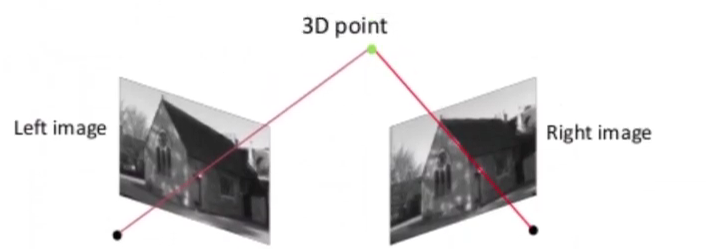







<font color="EB9A54">**Sistema de visión estéreo estandar**</font>

Al tener múltiples imágenes de una escena, es posible crear un mapa 3D de esa escena utilizando técnicas de visión estéreo. Esto no requiere dos cámaras, sino dos vistas diferentes de la escena. En este sentido, tenemos diferentes posibilidades:

- Dos camaras.
- Imágenes tomadas simultáneamente.
- Se conoce la pose relativa de las cámaras.

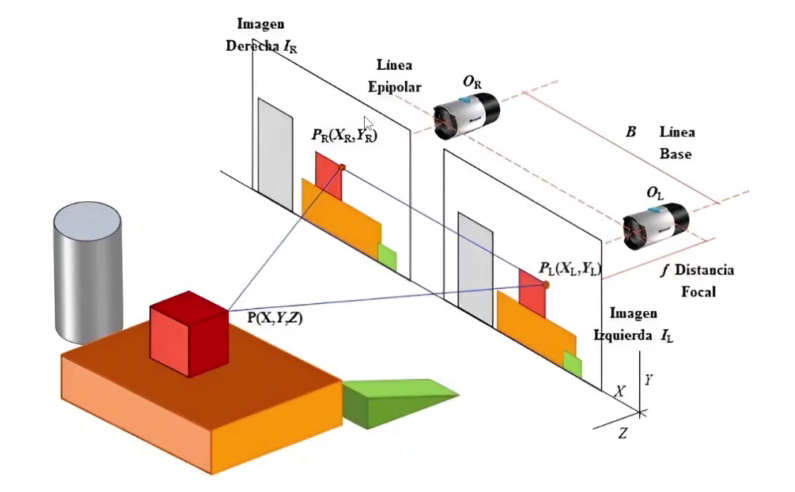



#  <font color='#4C5FDA'> **Caso N°1: Imágenes Rectificadas**</color> <a name="tema2">

Si partimos de imágenes que ya han sido previamente rectificadas, podemos omitir la calibración y rectificación, dos pasos que suelen requerir tiempo y recursos computacionales significativos.

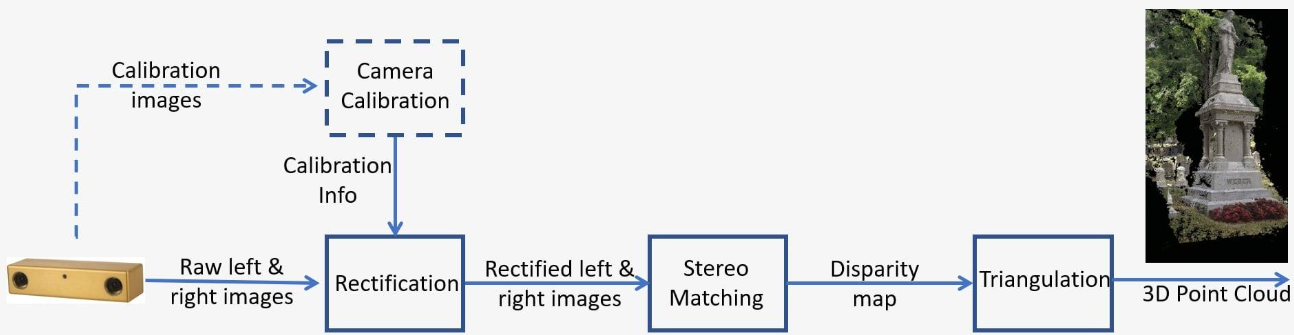

La ventaja de trabajar con imágenes rectificadas es inmediata: simplifica el flujo de trabajo de visión estérea y acelera el procesamiento, permitiéndonos centrarnos en la extracción de la profundidad y la interpretación tridimensional de la escena.

# <font color='#4C5FDA'> Middlebury Stereo Datasets

El Middlebury Stereo Dataset es uno de los benchmarks más reconocidos para visión estéreo. Proporciona pares estéreo de alta calidad con Imágenes rectificadas, mapas de disparidad ground truth precisos, condiciones de iluminación y texturas variadas.

En esta ocasión seleccionamos 3 escenas de 3 conjuntos de datos diferentes: `Tsukuba`, `Art` y `Bowling`.

<div align="center"> <image src="https://imgur.com/bcOKutr.png" width=600>  </div>


¿Como sabemos que realmente las imágenes ya están rectificadas?

### <font color="EB9A54"> **Prueba 1.1:** </font> Veamos los pares de imagenes


- Carga las imagenes del dataset `Tsukuba`, `Art` ó `Bowling`. Entre comillas "
- Visualiza las imagenes
- Notas alguna diferencia?

In [ ]:
#Ponemos el nombre del dataset que vamos a usar
nombre_dataset = "Art"
imgL, imgR = descargar_imagenes(nombre_dataset, "Color")
show_images(imgL,imgR, "Imagen Izquierda", "Imagen Derecha")

## <font color='#4C5FDA'>**1.1. Disparidad**</font> <a name="tema3">


## Disparidad

**La disparidad** es una medida clave en visión estéreo y representa la diferencia horizontal entre la posición de un mismo punto observado desde dos cámaras ligeramente separadas.

Cuando un punto en el mundo real es proyectado en ambas cámaras, su posición horizontal en la imagen izquierda (`X_l`) y en la imagen derecha (`X_r`) no es la misma. La **disparidad** se define como:

$$ \color{orange}{d = X_l - X_r} $$

donde:

- $d$ es la disparidad en píxeles  
- $X_l$ es la coordenada horizontal del punto en la imagen izquierda  
- $X_r$ es la coordenada horizontal correspondiente en la imagen derecha

En una configuración rectificada, esta diferencia ocurre **únicamente en el eje horizontal**, lo que simplifica el cálculo.

### Veremos dos algoritmos proporcionados por openCV

1. **StereoBM (Block Matching):**  
   - Método clásico, rápido y eficiente  
   - Adecuado para imágenes bien iluminadas y con buena textura  
   - Más sensible al ruido y oclusiones
   - Documentación: https://docs.opencv.org/3.4/d9/dba/classcv_1_1StereoBM.html

2. **StereoSGBM (Semi-Global Block Matching):**  
   - Extiende el bloque de comparación a lo largo de varias direcciones  
   - Mejora la consistencia espacial y la calidad del mapa de disparidad  
   - Requiere más tiempo de cómputo, pero ofrece mejores resultados
   - Documentación: https://docs.opencv.org/3.4/d2/d85/classcv_1_1StereoSGBM.html

Ambos métodos trabajan directamente sobre las imágenes **rectificadas**, donde las líneas epipolares están alineadas horizontalmente, permitiendo que la búsqueda de correspondencias se reduzca a una dimensión.



### <font color="EB9A54"> **Prueba 1.2:** </font> Aplicación de la visión estéreo y cálculo del mapa de disparidad

1. Utilizaremos las imágenes **ya cargadas** anteriormente (`imgL` e `imgR`)
2. Crearemos objetos de correspondencia estéreo usando `cv2.StereoBM_create()` y `cv2.StereoSGBM_create()`
3. Calcularemos los mapas de disparidad utilizando el método `.compute()`
4. Visualizaremos y compararemos ambos resultados variando los parámetros de `numDisparities` y `blockSize`.

Esto nos permitirá observar las diferencias en calidad y comportamiento entre ambos métodos.




In [ ]:
display(widgets.interact(compare_stereo_algorithms,
                         numDisparities=num_disp_slider,
                         blockSize=block_size_slider))


## <font color='#4C5FDA'>**1.2. Profundidad**</font> <a name="tema4"></a>

En visión estéreo, la **profundidad** hace referencia a la distancia entre un punto del mundo real y el plano de las cámaras. Es el valor que nos interesa recuperar para entender la estructura 3D de la escena.

Una vez obtenida la **disparidad** para cada píxel, podemos calcular la profundidad real utilizando la siguiente relación geométrica:

$$
\color{orange}{Z = \frac{f \cdot B}{d}}
$$

donde:

- $Z$ es la profundidad (en metros o milímetros)
- $f$ es la **distancia focal** de la cámara (en píxeles)
- $B$ es la **línea base** (*baseline*), es decir, la distancia física entre las dos cámaras
- $d$ es la disparidad en píxeles

---

### 📌 ¿Qué es la distancia focal y el baseline?

- **Distancia focal (`f`)**:  
  Es el valor que indica cuán “zoom” tiene la cámara. En este contexto, se mide en **píxeles** y proviene del proceso de calibración intrínseca. Es inherente a cada cámara.

- **Baseline (`B`)**:  
  Es la distancia **real** entre el centro óptico de la cámara izquierda y la derecha, generalmente medida en milímetros o metros. Cuanto mayor el baseline, más fácil detectar disparidades y estimar profundidad con precisión.




### <font color="EB9A54"> **Prueba 1.3:** </font> Cálculo mapa de profundidad

- Prueba valores distancia focal (entre 20 y 50px) y valores de baseline (entre 0.10 y 0.30 m)
- Calcula el mapa de profundidad siguiendo la fórmula vista anteriormente
- Umbraliza los valores del mapa de profundidad, buscando ver unicamente los objetos relevantes de la imagen ignorando el fondo y las zonas erroneas, siguiendo el histograma.



In [ ]:
f = 50  # distancia focal en píxeles
B = 0.16  # baseline en metros


#Acá generamos un disparity map con unos parámetros predeterminados, BlockSize de 13 y numDisparities de 16
disparity_map = stereo_sgdm(nombre_dataset)


Depth_map = (f*B)/disparity_map
Depth_map[(Depth_map < 0) | (Depth_map > 2)] = np.nan

visualizar_mapa_profundidad(Depth_map, umbral=10)



 ## <font color='#4C5FDA'>**1.3. Pointcloud - 3D**</font> <a name="tema5">


Después de obtener el mapa de profundidad usando imágenes estéreo, el siguiente paso es crear una nube de puntos 3D. Esta técnica transforma cada punto capturado en las imágenes en una posición tridimensional, brindando una vista detallada del entorno.

Para realizar esta conversión, es fundamental comprender la relación entre las coordenadas de los píxeles en la imagen, la profundidad de cada uno de estos píxeles, y su posición en el espacio tridimensional. Utilizando la distancia focal de la cámara <font color='#EB9A54'> **f** </font> , y las coordenadas del centro óptico de la imagen <font color='#EB9A54'> **(c_x, c_y)** </font>, podemos calcular la posición <font color='#EB9A54'> **X, Y, Z** </font> en el espacio de cada punto correspondiente a un píxel <font color='#EB9A54'> **(U, V)** </font> en la imagen, donde Z es la profundidad obtenida del mapa de profundidad.


La posición 3D de cada punto se calcula mediante las siguientes ecuaciones:

$$ X = \frac{(u - c_x) \cdot Z}{f} \ $$

 $$ Y = \frac{(v - c_y) \cdot Z}{f}  $$


Haciendo uso de la libreria de open3D un pointcloud puede verse de la siguiente manera:

In [ ]:
plot_3d(imgL, Depth_map)

Los resultados anteriores parten de una condición ideal: las imágenes provienen de un sistema estéreo calibrado y rectificado. Bajo esa configuración, la disparidad se calcula de forma directa porque los puntos correspondientes se buscan sobre la misma fila de ambas imágenes.

<font color="52F17F"> **¿Qué ocurre cuando las imágenes no están rectificadas o no conocemos de antemano la relación geométrica entre las cámaras? Lo veremos en la siguiente sección.** </font>


#  <font color='#4C5FDA'> **Caso N°2: Imágenes No Rectificadas**</color> <a name="tema6">

Cuando contamos con imágenes estéreo no rectificadas y no tenemos acceso a la calibración original de las cámaras, debemos abordar el proceso de rectificación de manera diferente. La rectificación se convierte en un paso crítico para alinear las imágenes de tal manera que los puntos correspondientes estén en la misma línea horizontal.

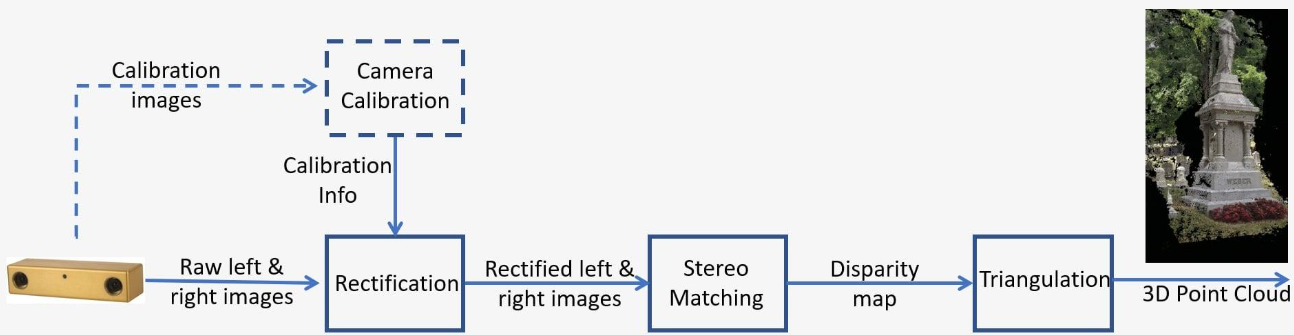

Este ajuste es esencial para el cálculo preciso de la disparidad y la extracción de la profundidad.

## <font color='#4C5FDA'>**2.1 Calibración de camara**</font> <a name="tema7">


Hasta ahora trabajamos con un par estéreo rectificado, donde las cámaras ya estaban alineadas y la búsqueda de correspondencias se podía hacer sobre la misma fila de ambas imágenes. En la práctica, muchas veces partimos de dos imágenes tomadas desde puntos de vista distintos, sin que estén alineadas de antemano.

Por ejemplo, imagina que visitas un monumento y tomas una fotografía. Tiempo después, otra persona toma una segunda fotografía del mismo monumento desde otra posición. Aunque ambas imágenes observan la misma escena, no sabemos directamente cómo se relacionan sus cámaras: una pudo estar rotada, desplazada o apuntando desde otro ángulo.

La calibración busca recuperar esa relación geométrica. Si conocemos los parámetros internos de cada cámara, podemos estimar la rotación y la traslación entre ambas vistas. Con esa información es posible rectificar las imágenes y volver al caso más simple: buscar correspondencias sobre líneas horizontales para construir un mapa de disparidad y, a partir de él, estimar profundidad.


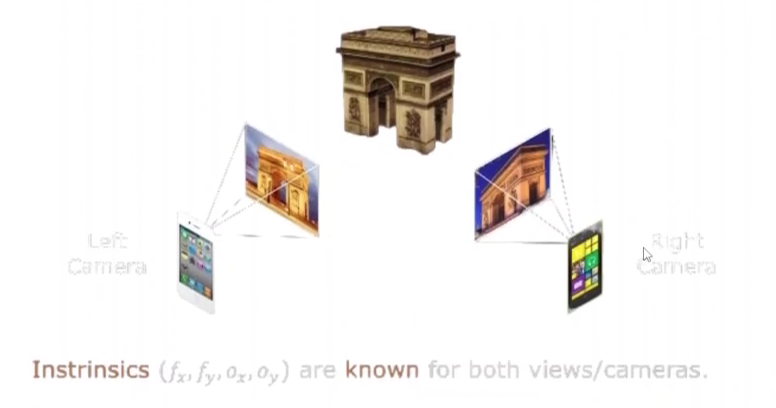

Cuando trabajamos con un par estéreo **no rectificado**, las imágenes no están alineadas horizontalmente. Es decir, los puntos correspondientes entre la imagen izquierda y derecha **no se encuentran en la misma línea horizontal**, lo que impide calcular la disparidad de forma directa.

## <font color='#4C5FDA'>**2.2. Rectificación**</font> <a name="tema8">

En la práctica, <font color='EB9A54'> **la triangulación precisa no es completamente factible ya que los sistemas estéreo no cumplen con la configuración ideal** </font>. Sin embargo, la buena noticia es que cualquier par de imágenes tomadas con cualquier configuración (siempre y cuando haya solapamiento entre las imágenes, por supuesto) puede ser transformado para que cumplan con una configuración ideal de cámara estéreo. Esto se denomina rectificación estéreo o rectificación de imagen.

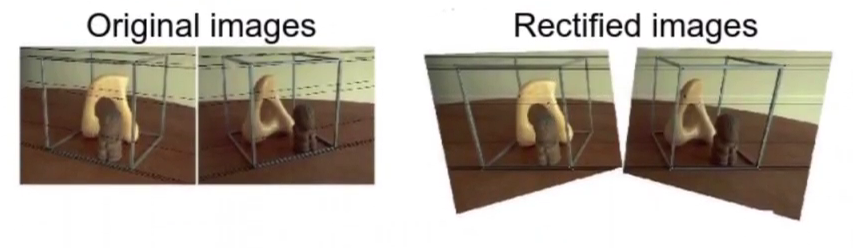






### <font color='#4C5FDA'>**2.2.1 Conceptos**</font> <a name="tema9">

En primer lugar tenemos el plano epipolar. Este plano está formado por 3 puntos: los centros ópticos izquierdo y derecho (Cl y Cr ), y un punto 3D en el mundo (X).

Para entender de dónde salen las líneas epipolares, pensemos en la geometría paso a paso:

1. Un punto 3D de la escena, $X$, se proyecta en dos imágenes: $X_l$ en la cámara izquierda y $X_r$ en la cámara derecha.
2. Los centros ópticos de las cámaras, $C_l$ y $C_r$, junto con el punto $X$, definen un único plano en el espacio. Ese plano se llama **plano epipolar**.
3. Ese mismo plano atraviesa los planos de imagen de ambas cámaras. La intersección entre el plano epipolar y cada plano de imagen produce una recta.
4. Esas rectas son las **líneas epipolares**: una en la imagen izquierda y otra en la imagen derecha.

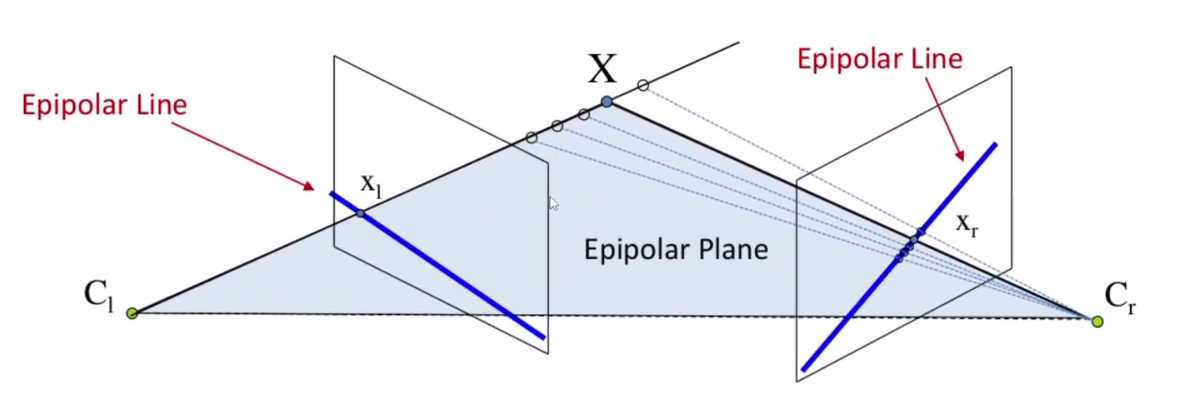

Como $X$, $C_l$ y $C_r$ pertenecen al mismo plano epipolar, sus proyecciones $X_l$ y $X_r$ necesariamente caen sobre las líneas epipolares correspondientes. Por eso, si conocemos un punto en una imagen, su correspondencia en la otra imagen no puede estar en cualquier lugar: debe estar sobre su línea epipolar.

Esta es la idea clave para reducir el problema de correspondencias. En lugar de buscar el punto correspondiente en toda la imagen derecha, basta con buscarlo sobre una línea. Después de rectificar las imágenes, esas líneas se vuelven horizontales y quedan alineadas por filas, que es el caso que usamos para calcular disparidad.



<br>
<br>



# 👀 Rectificación de imágenes no rectificadas

Usaremos dos imágenes del dataset ETH3D `courtyard`. La pareja no está rectificada, así que sirve para visualizar cómo pasamos de imágenes originales a imágenes rectificadas usando keypoints, la matriz fundamental y homografías.


In [ ]:
#@title Cargamos un par ETH3D no rectificado { display-mode: "form" }
eth3d_base_url = "https://raw.githubusercontent.com/cvail-research/Hands-on-Computer-Vision/main/sesiones/sesion5/Datasets/ETH3D/courtyard/{}"
eth3d_dir = resolver_ruta_sesion5("Datasets", "ETH3D", "courtyard")

def cargar_imagen_eth3d(nombre_archivo, size=(384, 256)):
    ruta_local = eth3d_dir / nombre_archivo
    if ruta_local.exists():
        image = Image.open(ruta_local)
    else:
        url = eth3d_base_url.format(nombre_archivo)
        response = requests.get(url)
        if response.status_code != 200:
            raise FileNotFoundError(
                f"No se encontró {ruta_local} ni se pudo descargar {url}. "
                "Verifica que las imágenes ETH3D estén subidas al repositorio."
            )
        image = Image.open(BytesIO(response.content))

    return np.array(image.convert("RGB").resize(size, Image.LANCZOS))

imgLeft = cargar_imagen_eth3d("DSC_0290.JPG")
imgRight = cargar_imagen_eth3d("DSC_0292.JPG")

show_images(imgLeft, imgRight, "Imagen izquierda ETH3D", "Imagen derecha ETH3D")


### <font color='#4C5FDA'>**2.2.2 KeyPoints**</font> <a name="tema11"></a>

En visión estéreo con imágenes no rectificadas, uno de los pasos clave es encontrar y emparejar **puntos característicos** entre ambas imágenes. Este proceso nos permite establecer correspondencias para calcular la geometría epipolar.

Se compone de los siguientes pasos:

1. **Detección de Keypoints con SIFT**  
   Utilizamos SIFT (Scale-Invariant Feature Transform) para detectar puntos clave y calcular sus descriptores en ambas imágenes.  
   📄 [Docs SIFT](https://docs.opencv.org/3.4/d7/d60/classcv_1_1SIFT.html)

2. **Emparejamiento con FLANN**  
   Usamos el matcher FLANN (Fast Library for Approximate Nearest Neighbors) para encontrar correspondencias entre descriptores.  
   📄 [Docs FLANN](https://docs.opencv.org/3.4/dc/dc3/tutorial_py_matcher.html)

3. **Filtrado con el Ratio Test de Lowe**  
   Para eliminar emparejamientos incorrectos, aplicamos el *ratio test* (típicamente con umbral 0.8), quedándonos solo con correspondencias fiables.


In [ ]:
#@title Keypoints { display-mode: "form" }
if imgLeft.ndim == 3:
    imgLeft = cv.cvtColor(imgLeft, cv.COLOR_RGB2GRAY)
if imgRight.ndim == 3:
    imgRight = cv.cvtColor(imgRight, cv.COLOR_RGB2GRAY)

sift = cv.SIFT_create()
keyPointsLeft, descriptorsLeft = sift.detectAndCompute(imgLeft, None)
keyPointsRight, descriptorsRight = sift.detectAndCompute(imgRight, None)

if descriptorsLeft is None or descriptorsRight is None:
    raise ValueError("No se encontraron descriptores suficientes en una de las imágenes.")

FLANN_INDEX_KDTREE = 1
indexParams = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
searchParams = dict(checks=50)
flann = cv.FlannBasedMatcher(indexParams, searchParams)

goodMatches = []
ptsLeft = []
ptsRight = []
matches = flann.knnMatch(descriptorsLeft, descriptorsRight, k=2)

print(f"Número de coincidencias antes del test de ratio: {len(matches)}")

for m, n in matches:
    if m.distance < 0.8 * n.distance:
        goodMatches.append(m)
        ptsLeft.append(keyPointsLeft[m.queryIdx].pt)
        ptsRight.append(keyPointsRight[m.trainIdx].pt)

print(f"Número de buenas coincidencias después del test de ratio: {len(goodMatches)}")

if len(goodMatches) < 8:
    raise ValueError("Se necesitan al menos 8 buenas correspondencias para estimar la matriz fundamental.")


A partir de este par calcularemos correspondencias, estimaremos la matriz fundamental y obtendremos las homografías necesarias para rectificar las imágenes.


In [ ]:
#@title Veamos algunos emparejamientos de nuestro algoritmo { display-mode: "form" }

parejas = random.sample(goodMatches,min(30, len(goodMatches)))
imgMatches = cv.drawMatches(imgLeft, keyPointsLeft, imgRight, keyPointsRight, parejas , None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(20,10))
plt.imshow(imgMatches)
plt.title("Emparejamientos encontrados")
plt.show()

### <font color='#4C5FDA'>**2.2.3 Matriz Fundamental**</font> <a name="tema12"></a>

La **matriz fundamental (F)** describe la relación geométrica entre dos imágenes no rectificadas. Para cada punto en una imagen, F define la **línea epipolar** sobre la que debe estar su correspondiente en la otra imagen.

Usamos `cv.findFundamentalMat()` con el método `cv.FM_LMEDS`, que permite estimar F de forma robusta incluso con **outliers**, eligiendo automáticamente el modelo que mejor se ajusta a la mayoría de las correspondencias.

Esta matriz es clave para tareas como **rectificación**, **reconstrucción 3D** y **estimación de la pose relativa** entre cámaras.

📄 [findFundamentalMat (OpenCV)](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html)


In [ ]:
#@title Obtenemos la matriz fundamental { display-mode: "form" }
ptsLeft = np.float32(ptsLeft)
ptsRight = np.float32(ptsRight)
F, mask = cv.findFundamentalMat(ptsLeft, ptsRight, cv.FM_RANSAC, 1.0, 0.99)

if F is None or mask is None:
    raise RuntimeError("No fue posible estimar la matriz fundamental con las correspondencias encontradas.")

ptsLeft = ptsLeft[mask.ravel() == 1]
ptsRight = ptsRight[mask.ravel() == 1]

print(f"Correspondencias inlier usadas para F: {len(ptsLeft)}")
print(F)


### <font color='#4C5FDA'>**2.2.4 Líneas Epipolares**</font> <a name="tema13"></a>

Las **líneas epipolares** indican dónde debe encontrarse la correspondencia de un punto entre dos imágenes no rectificadas. Cada punto en una imagen tiene una línea asociada en la otra imagen sobre la cual debe estar su correspondiente.

Para calcular estas líneas, usamos la **matriz fundamental (F)** junto con la función `cv.computeCorrespondEpilines()`, que genera las líneas epipolares correspondientes a un conjunto de puntos.

📄 [computeCorrespondEpilines (OpenCV)](https://amroamroamro.github.io/mexopencv/matlab/cv.computeCorrespondEpilines.html)


In [ ]:
#@title Veamos algunas lineas epipolares { display-mode: "form" }
linesLeft = cv.computeCorrespondEpilines(ptsRight.reshape(-1, 1, 2), 2, F)
linesLeft = linesLeft.reshape(-1, 3)
img5 = drawlines(imgLeft, imgRight, linesLeft, ptsLeft, ptsRight)

linesRight = cv.computeCorrespondEpilines(ptsLeft.reshape(-1, 1, 2), 1, F)
linesRight = linesRight.reshape(-1, 3)
img3 = drawlines(imgRight, imgLeft, linesRight, ptsRight, ptsLeft)

show_images(img5,img3, "Imagen Izquierda con Lineas Epipolares", "Imagen Derecha con Lineas Epipolares")



### <font color='#4C5FDA'>**2.2.5 Homografías**</font> <a name="tema14"></a>

Las **homografías** permiten transformar planos entre imágenes mediante una proyección. En visión estéreo, las usamos para **rectificar imágenes no calibradas**.

Con `cv.stereoRectifyUncalibrated()` calculamos las homografías `H1` y `H2` a partir de las correspondencias y la matriz fundamental. Luego, aplicamos esas transformaciones con `cv.warpPerspective()` para alinear las imágenes y que sus puntos correspondan en líneas horizontales.

Este paso convierte un par no rectificado en uno listo para calcular disparidad y profundidad.

📄 [stereoRectifyUncalibrated (OpenCV)](https://amroamroamro.github.io/mexopencv/matlab/cv.stereoRectifyUncalibrated.html)  
📄 [warpPerspective (OpenCV)](https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html)


In [ ]:
#@title Asi son las homografías { display-mode: "form" }
image_size = (imgLeft.shape[1], imgLeft.shape[0])
ok, h1, h2 = cv.stereoRectifyUncalibrated(np.float32(ptsLeft), np.float32(ptsRight), F, image_size)

if not ok:
    raise RuntimeError("No fue posible calcular las homografías de rectificación para este par de imágenes.")

# Aplicar las homografías para rectificar las imágenes
imgLeftRectified = cv.warpPerspective(imgLeft, h1, image_size)
imgRightRectified = cv.warpPerspective(imgRight, h2, image_size)
show_images(imgLeftRectified, imgRightRectified, "Imagen Izquierda Rectificada", "Imagen Derecha Rectificada")


Comprobemos que las lineas epipolares ya se encuentran de manera horizontal, con ello verificamos que la imagen ya está rectificada.

In [ ]:
#@title Asi se ven las imagenes rectificadas con sus lineas epipolares { display-mode: "form" }
imgLeftWithEpilines, imgRightWithEpilines = add_epilines_to_rectified_images(imgLeftRectified, imgRightRectified, ptsLeft, ptsRight, h1, h2)
show_images(imgLeftWithEpilines, imgRightWithEpilines, "Left Image with Epilines", "Right Image with Epilines")


## <font color='#4C5FDA'>**2.3 Disparidad**</font> <a name="tema15">

Ya con nuestras imágenes rectificadas podemos ejecutar nuevamente el calculo del mapa de disparidad, al igual como hicimos en el paso anterior.

In [ ]:
#@title Mapa de disparidad { display-mode: "form" }
stereo_nonrecti = cv.StereoSGBM_create(numDisparities=32, blockSize=21)
disp_nonrecti = stereo_nonrecti.compute(imgLeftRectified, imgRightRectified).astype(np.float32) / 16.0
plot_disparitymap(imgLeftRectified, imgRightRectified, disp_nonrecti)


## <font color='#4C5FDA'>**2.4 Profundidad**</font> <a name="tema16">

Ya teniendo nuestro mapa de disparidad, podemos calcular el mapa de profundidad. Ya que no tenemos los datos de las cámaras con las que fueron tomadas las fotos, debemos asumir algunos valores para poder calcular el mapa de profundidad

In [ ]:
#@title Profundidad sistema no rectificado { display-mode: "form" }
f = 34 # distancia focal en píxeles
B = 0.3  # baseline en milímetros

Z = (f * B) / disp_nonrecti
Z[(Z <= 0) | (Z > 10)] = np.nan

visualizar_mapa_profundidad(Z, umbral=10)


## <font color='#4C5FDA'>**2.5 PointCloud - 3D**</font> <a name="tema17">

Finalmente, usamos el mapa de profundidad estimado para construir una nube de puntos 3D, siguiendo el mismo procedimiento del caso con imágenes rectificadas.


In [ ]:
#@title Nube de puntos 3D sistema no rectificado { display-mode: "form" }
if imgLeftRectified.ndim == 2:
    imgLeftRectifiedColor = cv.cvtColor(imgLeftRectified, cv.COLOR_GRAY2RGB)
else:
    imgLeftRectifiedColor = imgLeftRectified

plot_3d(imgLeftRectifiedColor, Z)
